# Physics-Informed Neural Network for the 1D Schrödinger Equation

This notebook solves the **1D time-independent Schrödinger equation** for a particle in an **infinite square well** using a Physics-Informed Neural Network, abbreviated as PINN.

The system is deliberately chosen because it has a known analytical solution. This allows us to compare the neural-network solution with the exact quantum-mechanical wavefunction and energy.

The main goals of this notebook are:

1. define the infinite square well problem,
2. construct a neural-network ansatz for the wavefunction,
3. enforce the Schrödinger equation through a physics residual,
4. enforce normalization of the wavefunction,
5. compare fixed-energy and trainable-energy PINN models,
6. evaluate the learned wavefunction against the analytical ground state.

---

## Physical system: infinite square well

We consider a particle confined to the interval:

$$
x \in [0,1]
$$

The potential is zero inside the well and infinite outside the well. Therefore, the particle must remain inside the interval, and the wavefunction must vanish at the boundaries:

$$
\psi(0)=0
$$

$$
\psi(1)=0
$$

Using dimensionless units,

$$
\frac{\hbar^2}{2m}=1
$$

and

$$
L=1
$$

the time-independent Schrödinger equation inside the well becomes:

$$
-\frac{d^2\psi(x)}{dx^2}=E\psi(x)
$$

Here:

- $\psi(x)$ is the wavefunction,
- $E$ is the energy eigenvalue,
- $x$ is the position inside the well.

The analytical eigenfunctions are:

$$
\psi_n(x)=\sqrt{2}\sin(n\pi x)
$$

and the corresponding energy eigenvalues are:

$$
E_n=n^2\pi^2
$$

In this notebook, we focus mainly on the ground state:

$$
n=1
$$

Therefore:

$$
\psi_1(x)=\sqrt{2}\sin(\pi x)
$$

and

$$
E_1=\pi^2
$$

## 1. Imports and computational setup

This cell imports the libraries required for the PINN implementation.

We use:

- `torch` for neural networks and automatic differentiation,
- `numpy` for numerical utilities,
- `matplotlib` for plotting,
- `math` for constants such as $\pi$.

The device is selected automatically:

$$
\text{device} =
\begin{cases}
\text{GPU}, & \text{if CUDA is available} \\
\text{CPU}, & \text{otherwise}
\end{cases}
$$

For this small PINN example, CPU execution is already sufficient, but the code also supports GPU execution.

In [38]:

# ============================================================
# Imports and setup
# ============================================================

import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# On CPU, limiting threads often makes small PINN examples much faster and more stable.
if not torch.cuda.is_available():
    torch.set_num_threads(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)


PyTorch version: 2.11.0+cpu
Using device: cpu


## 2. Analytical ground-state solution

For the ground state of the 1D infinite square well, the exact normalized wavefunction is:

$$
\psi_1(x)=\sqrt{2}\sin(\pi x)
$$

The corresponding exact energy is:

$$
E_1=\pi^2
$$

This exact solution is not used as labeled training data. Instead, it is used only after training to evaluate how well the PINN has learned the physical solution.

This is important because the PINN is not trained in the usual supervised-learning way. It learns by minimizing the residual of the differential equation and by satisfying physical constraints such as normalization and boundary conditions.

In [39]:
# ============================================================
# Analytical solution
# ============================================================

def exact_psi_ground(x):
    """
    Exact normalized ground-state wavefunction for the infinite square well on [0, 1].
    x must be a torch tensor.
    """
    return math.sqrt(2.0) * torch.sin(math.pi * x)


E_exact = math.pi**2
#E_exact =  9

print(f"Exact ground-state energy E1 = pi^2 = {E_exact:.8f}")


Exact ground-state energy E1 = pi^2 = 9.86960440


## 3. PINN idea

The neural network takes the position \(x\) as input and produces a scalar output. This output is used to construct an approximate wavefunction.

The neural-network approximation is written as:

$$
\psi_\theta(x)
$$

where \( \theta \) represents the trainable parameters of the neural network.

The time-independent Schrödinger equation is:

$$
-\frac{d^2\psi(x)}{dx^2}=E\psi(x)
$$

For the PINN approximation, we define the physics residual as:

$$
R_\theta(x)
=
-\frac{d^2\psi_\theta(x)}{dx^2}
-
E\psi_\theta(x)
$$

If the network satisfies the Schrödinger equation exactly, then the residual should be zero:

$$
R_\theta(x)=0
$$

Therefore, the PDE loss is defined as the mean squared residual over collocation points:

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
R_\theta(x_i)
\right)^2
$$

Substituting the residual explicitly:

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
-\frac{d^2\psi_\theta(x_i)}{dx^2}
-
E\psi_\theta(x_i)
\right)^2
$$

The wavefunction must also be normalized:

$$
\int_0^1 |\psi_\theta(x)|^2 dx = 1
$$

So we define a normalization loss:

$$
\mathcal{L}_{\mathrm{norm}}
=
\left(
\int_0^1 |\psi_\theta(x)|^2 dx
-
1
\right)^2
$$

The total loss is:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\lambda_{\mathrm{norm}}
\mathcal{L}_{\mathrm{norm}}
$$

where $\lambda_{\mathrm{norm}}$ controls how strongly the normalization condition is enforced.

---

## Boundary-condition ansatz

The infinite square well requires:

$$
\psi(0)=0
$$

and

$$
\psi(1)=0
$$

Instead of adding boundary-condition loss terms, we enforce these conditions exactly by defining the wavefunction as:

$$
\psi_\theta(x)
=
x(1-x)N_\theta(x)
$$

Here, $N_\theta(x)$ is the raw output of the neural network.

This automatically gives:

$$
\psi_\theta(0)=0
$$

and

$$
\psi_\theta(1)=0
$$

because the factor $x(1-x)$ vanishes at both boundaries.

Important note: $N_\theta(x)$ is not the normalization constant. It is simply the neural network output. The normalization of the full wavefunction $\psi_\theta(x)$ is enforced separately through the normalization loss.

## 4. Neural network and PINN utilities

This cell defines the neural network and the main physics-informed components.

The model has two parts:

1. a standard fully connected neural network,
2. a physics-informed wrapper that converts the raw network output into a valid wavefunction ansatz.

The multilayer perceptron produces:

$$
N_\theta(x)
$$

The physical wavefunction is then constructed as:

$$
\psi_\theta(x)=x(1-x)N_\theta(x)
$$

The factor $x(1-x)$ enforces the boundary conditions exactly.

---

## Automatic differentiation

To evaluate the Schrödinger equation, we need the second derivative:

$$
\frac{d^2\psi_\theta(x)}{dx^2}
$$

Instead of approximating this derivative using finite differences, PyTorch automatic differentiation is used.

First, the code computes:

$$
\frac{d\psi_\theta(x)}{dx}
$$

Then it differentiates again to obtain:

$$
\frac{d^2\psi_\theta(x)}{dx^2}
$$

This is one of the key ideas behind PINNs: the neural network is differentiable, so derivatives appearing in differential equations can be computed directly by automatic differentiation.

---

## Energy handling

The model supports two cases.

In the fixed-energy case, the energy is fixed to the analytical ground-state value:

$$
E=\pi^2
$$

In the trainable-energy case, the energy is learned as a model parameter.

To keep the learned energy positive, the code uses a softplus parametrization:

$$
E=\operatorname{softplus}(a)
$$

where \(a\) is an unconstrained trainable parameter.

This ensures:

$$
E>0
$$

which is physically appropriate for the infinite square well.

In [40]:

# ============================================================
# Neural network and PINN utilities
# ============================================================

class MLP(nn.Module):
    """
    Simple fully connected neural network.
    Tanh activation is commonly used in PINNs because it is smooth,
    which helps when computing derivatives using autograd.
    """
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1, num_hidden_layers=3):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class SchrodingerPINN(nn.Module):
    """
    PINN model for the 1D infinite square well.

    The output is multiplied by x(1-x), so boundary conditions are satisfied exactly:
        psi(0) = psi(1) = 0

    Two modes are supported:
        1. Fixed energy E
        2. Trainable energy E
    """
    def __init__(self, trainable_energy=False, fixed_energy=math.pi**2, init_energy=8.0):
        super().__init__()

        self.network = MLP(
            input_dim=1,
            hidden_dim=32,
            output_dim=1,
            num_hidden_layers=3
        )

        self.trainable_energy = trainable_energy

        if trainable_energy:
            # We parameterize E using softplus(raw_E), so E stays positive.
            # raw_E is initialized so that softplus(raw_E) is approximately init_energy.
            raw_init = math.log(math.exp(init_energy) - 1.0)
            self.raw_E = nn.Parameter(torch.tensor(raw_init, dtype=torch.float32))
        else:
            self.register_buffer(
                "fixed_E",
                torch.tensor(float(fixed_energy), dtype=torch.float32)
            )

    def energy(self):
        if self.trainable_energy:
            return torch.nn.functional.softplus(self.raw_E) + 1e-6
        return self.fixed_E

    def forward(self, x):
        raw_output = self.network(x)
        psi = x * (1.0 - x) * raw_output
        return psi


def second_derivative(y, x):
    """
    Compute d^2y/dx^2 using PyTorch automatic differentiation.
    """
    dy_dx = torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    d2y_dx2 = torch.autograd.grad(
        dy_dx,
        x,
        grad_outputs=torch.ones_like(dy_dx),
        create_graph=True
    )[0]

    return d2y_dx2


def wavefunction_norm(psi, x):
    """
    Approximate integral of |psi(x)|^2 from x=0 to x=1 using the trapezoidal rule.
    """
    return torch.trapezoid(psi.squeeze()**2, x.squeeze())


def pinn_loss(model, x_collocation, norm_weight=100.0, energy_penalty_weight=0.0):
    """
    Compute the full PINN loss:
        loss = PDE loss + norm_weight * normalization loss

    For the trainable-energy case, a small energy penalty can be added.
    This weakly encourages the lowest eigenvalue, i.e. the ground state.
    """
    x = x_collocation.clone().detach().requires_grad_(True)

    psi = model(x)
    psi_xx = second_derivative(psi, x)

    E = model.energy()
    residual = -psi_xx - E * psi

    pde_loss = torch.mean(residual**2)

    norm = wavefunction_norm(psi, x)
    norm_loss = (norm - 1.0)**2

    total_loss = pde_loss + norm_weight * norm_loss

    if energy_penalty_weight > 0:
        total_loss = total_loss + energy_penalty_weight * E**2

    return total_loss, pde_loss, norm_loss, norm, E


## 5. Training and evaluation helper functions

The training points are called collocation points.

These are points inside the spatial domain:

$$
x_i \in [0,1]
$$

They are not labeled data points. Instead, they are points where the differential equation is enforced.

At every training step, the model performs the following operations:

1. evaluate the wavefunction $\psi_\theta(x_i)$,
2. compute the second derivative using automatic differentiation,
3. build the Schrödinger residual,
4. compute the PDE loss,
5. compute the normalization loss,
6. combine the losses,
7. update the neural-network parameters using Adam.

The residual is:

$$
R_\theta(x_i)
=
-\frac{d^2\psi_\theta(x_i)}{dx^2}
-
E\psi_\theta(x_i)
$$

The PDE loss is:

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{N}
\sum_{i=1}^{N}
R_\theta(x_i)^2
$$

The normalization integral is approximated numerically using the trapezoidal rule:

$$
\int_0^1 |\psi_\theta(x)|^2 dx
\approx
\operatorname{trapz}
\left(
|\psi_\theta(x)|^2
\right)
$$

The final loss is:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\lambda_{\mathrm{norm}}
\mathcal{L}_{\mathrm{norm}}
$$

For the trainable-energy case, a small additional energy penalty may be added:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\lambda_{\mathrm{norm}}
\mathcal{L}_{\mathrm{norm}}
+
\lambda_E E^2
$$

This weakly encourages the network to choose the lowest-energy solution, which corresponds to the ground state.

In [41]:

# ============================================================
# Training and evaluation helpers
# ============================================================

def train_pinn(
    model,
    x_collocation,
    epochs=3000,
    lr=2e-3,
    norm_weight=10.0,
    energy_penalty_weight=0.0,
    print_every=500
):
    """
    Train a PINN model and return a history dictionary.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "epoch": [],
        "total_loss": [],
        "pde_loss": [],
        "norm_loss": [],
        "norm": [],
        "energy": []
    }

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss, pde_loss, norm_loss, norm, E = pinn_loss(
            model,
            x_collocation,
            norm_weight=norm_weight,
            energy_penalty_weight=energy_penalty_weight
        )

        total_loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            history["epoch"].append(epoch)
            history["total_loss"].append(total_loss.item())
            history["pde_loss"].append(pde_loss.item())
            history["norm_loss"].append(norm_loss.item())
            history["norm"].append(norm.item())
            history["energy"].append(E.item())

            print(
                f"Epoch {epoch:5d} | "
                f"Total Loss = {total_loss.item():.4f} | "
                f"PDE Loss = {pde_loss.item():.4f} | "
                f"Norm = {norm.item():.6f} | "
                f"E = {E.item():.6f}"
            )

    return history


def evaluate_model(model, num_points=1001):
    """
    Evaluate the trained model against the analytical ground-state solution.
    Because eigenfunctions are defined up to an overall sign, we align the sign
    of the PINN solution with the exact solution before calculating errors.
    """
    x_eval = torch.linspace(0.0, 1.0, num_points, device=device).reshape(-1, 1)

    with torch.no_grad():
        psi_pred = model(x_eval).squeeze()
        psi_exact = exact_psi_ground(x_eval).squeeze()

        # Align sign, since both psi and -psi are valid eigenfunctions.
        if torch.mean(psi_pred * psi_exact) < 0:
            psi_pred = -psi_pred

        mse = torch.mean((psi_pred - psi_exact)**2).item()
        max_abs_error = torch.max(torch.abs(psi_pred - psi_exact)).item()
        norm = torch.trapezoid(psi_pred**2, x_eval.squeeze()).item()
        energy = model.energy().item()

    return {
        "x": x_eval.detach().cpu().numpy().squeeze(),
        "psi_pred": psi_pred.detach().cpu().numpy(),
        "psi_exact": psi_exact.detach().cpu().numpy(),
        "mse": mse,
        "max_abs_error": max_abs_error,
        "norm": norm,
        "energy": energy
    }


def plot_loss_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.semilogy(history["epoch"], history["total_loss"], marker="o", label="Total loss")
    plt.semilogy(history["epoch"], history["pde_loss"], marker="o", label="PDE loss")
    plt.semilogy(history["epoch"], history["norm_loss"], marker="o", label="Normalization loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_wavefunction(results, title):
    x = results["x"]
    psi_pred = results["psi_pred"]
    psi_exact = results["psi_exact"]

    plt.figure(figsize=(8, 5))
    plt.plot(x, psi_exact, linewidth=2, label="Exact $\\psi_1(x)$")
    plt.plot(x, psi_pred, "--", linewidth=2, label="PINN prediction")
    plt.xlabel("$x$")
    plt.ylabel("$\\psi(x)$")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_probability_density(results, title):
    x = results["x"]
    psi_pred = results["psi_pred"]
    psi_exact = results["psi_exact"]

    plt.figure(figsize=(8, 5))
    plt.plot(x, psi_exact**2, linewidth=2, label="Exact $|\\psi_1(x)|^2$")
    plt.plot(x, psi_pred**2, "--", linewidth=2, label="PINN $|\\psi(x)|^2$")
    plt.xlabel("$x$")
    plt.ylabel("$|\\psi(x)|^2$")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def print_evaluation(name, results):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"Predicted energy      : {results['energy']:.8f}")
    print(f"Exact energy          : {E_exact:.8f}")
    print(f"Absolute energy error : {abs(results['energy'] - E_exact):.4e}")
    print(f"Wavefunction MSE      : {results['mse']:.4e}")
    print(f"Max absolute error    : {results['max_abs_error']:.4e}")
    print(f"Normalization integral: {results['norm']:.8f}")


## 6. Case A: Fixed-energy PINN

In the first experiment, the correct ground-state energy is given to the model:

$$
E=\pi^2
$$

Therefore, the neural network only needs to learn the wavefunction:

$$
\psi_\theta(x)
$$

This is the simplest and most stable version of the PINN problem because the eigenvalue is already known.

The model is trained by minimizing:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\lambda_{\mathrm{norm}}
\mathcal{L}_{\mathrm{norm}}
$$

where the PDE loss enforces:

$$
-\frac{d^2\psi_\theta(x)}{dx^2}
=
\pi^2\psi_\theta(x)
$$

and the normalization loss enforces:

$$
\int_0^1 |\psi_\theta(x)|^2 dx=1
$$

In [42]:

# ============================================================
# Fixed-energy PINN
# ============================================================

# Collocation points where the PDE is enforced
x_collocation = torch.linspace(0.0, 1.0, 81, device=device).reshape(-1, 1)

fixed_energy_model = SchrodingerPINN(
    trainable_energy=False,
    fixed_energy=E_exact
).to(device)

fixed_history = train_pinn(
    model=fixed_energy_model,
    x_collocation=x_collocation,
    epochs=300,
    lr=2e-3,
    norm_weight=10.0,
    energy_penalty_weight=0.0,
    print_every=10
)


Epoch     1 | Total Loss = 10.0086 | PDE Loss = 0.0103 | Norm = 0.000084 | E = 9.869604
Epoch    10 | Total Loss = 9.9682 | PDE Loss = 0.0874 | Norm = 0.005980 | E = 9.869604
Epoch    20 | Total Loss = 9.6354 | PDE Loss = 0.9852 | Norm = 0.069937 | E = 9.869604
Epoch    30 | Total Loss = 8.5349 | PDE Loss = 1.7514 | Norm = 0.176379 | E = 9.869604
Epoch    40 | Total Loss = 5.5006 | PDE Loss = 1.1322 | Norm = 0.339059 | E = 9.869604
Epoch    50 | Total Loss = 1.4163 | PDE Loss = 0.4490 | Norm = 0.688975 | E = 9.869604
Epoch    60 | Total Loss = 0.1511 | PDE Loss = 0.1289 | Norm = 1.047141 | E = 9.869604
Epoch    70 | Total Loss = 0.0881 | PDE Loss = 0.0109 | Norm = 1.087873 | E = 9.869604
Epoch    80 | Total Loss = 0.0624 | PDE Loss = 0.0248 | Norm = 0.938730 | E = 9.869604
Epoch    90 | Total Loss = 0.0072 | PDE Loss = 0.0052 | Norm = 1.014110 | E = 9.869604
Epoch   100 | Total Loss = 0.0065 | PDE Loss = 0.0059 | Norm = 1.007683 | E = 9.869604
Epoch   110 | Total Loss = 0.0021 | PDE Lo

## 7. Fixed-energy evaluation and plots

After training the fixed-energy PINN, we compare its prediction with the exact ground-state solution:

$$
\psi_1(x)=\sqrt{2}\sin(\pi x)
$$

The notebook evaluates:

- predicted energy,
- exact energy,
- absolute energy error,
- wavefunction mean squared error,
- maximum absolute wavefunction error,
- normalization integral.

The wavefunction is only physically meaningful up to an overall sign. This means both solutions are equivalent:

$$
\psi(x)
$$

and

$$
-\psi(x)
$$

Therefore, before computing errors, the predicted wavefunction is sign-aligned with the exact wavefunction.

The probability density is computed as:

$$
|\psi(x)|^2
$$

For the normalized ground state of the infinite square well:

$$
|\psi_1(x)|^2
=
2\sin^2(\pi x)
$$

This probability density integrates to one:

$$
\int_0^1 |\psi_1(x)|^2 dx=1
$$

However, its maximum value is:

$$
\max_x |\psi_1(x)|^2 = 2
$$

So it is completely correct for the probability density plot to peak at 2. A probability density can be larger than 1; only the total integral over space must equal 1.


Fixed-energy PINN results
-------------------------
Predicted energy      : 9.86960411
Exact energy          : 9.86960440
Absolute energy error : 2.9037e-07
Wavefunction MSE      : 5.0294e-10
Max absolute error    : 5.5015e-05
Normalization integral: 1.00003040


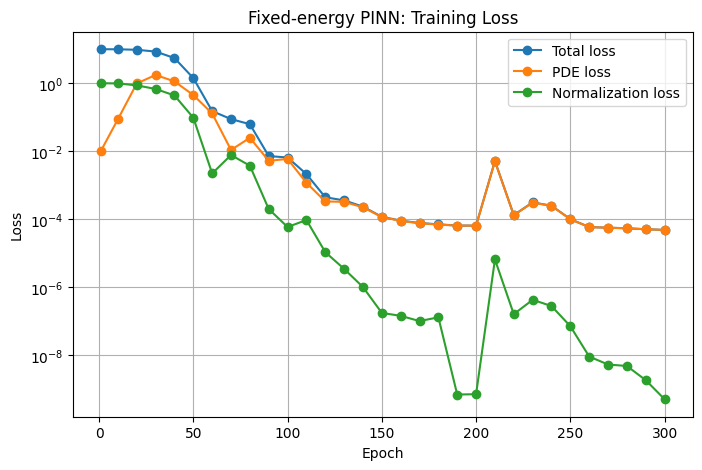

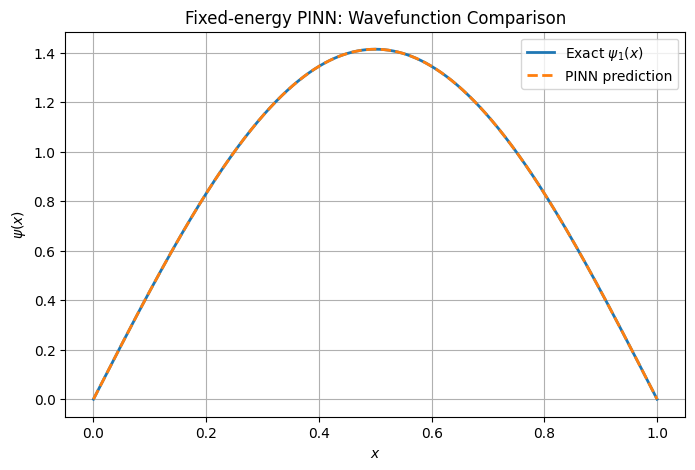

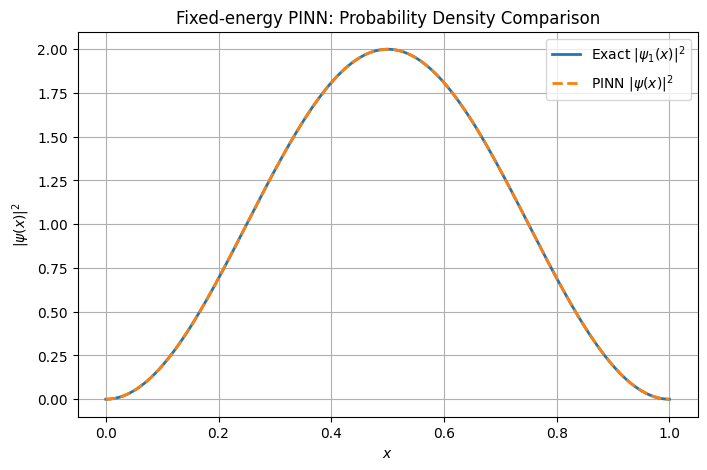

In [43]:

# ============================================================
# Fixed-energy evaluation and plots
# ============================================================

fixed_results = evaluate_model(fixed_energy_model)

print_evaluation("Fixed-energy PINN results", fixed_results)

plot_loss_history(
    fixed_history,
    title="Fixed-energy PINN: Training Loss"
)

plot_wavefunction(
    fixed_results,
    title="Fixed-energy PINN: Wavefunction Comparison"
)

plot_probability_density(
    fixed_results,
    title="Fixed-energy PINN: Probability Density Comparison"
)


## 8. Case B: Trainable-energy PINN

In the second experiment, the energy is not fixed.

The model learns both the wavefunction:

$$
\psi_\theta(x)
$$

and the energy eigenvalue:

$$
E
$$

The Schrödinger residual is still:

$$
R_\theta(x)
=
-\frac{d^2\psi_\theta(x)}{dx^2}
-
E\psi_\theta(x)
$$

The model must find a pair $(\psi_\theta,E)$ that satisfies:

$$
-\frac{d^2\psi_\theta(x)}{dx^2}
=
E\psi_\theta(x)
$$

The infinite square well has multiple valid eigenstates:

$$
\psi_n(x)=\sqrt{2}\sin(n\pi x)
$$

with energies:

$$
E_n=n^2\pi^2
$$

This means the model could, in principle, learn a higher-energy state. To encourage the ground state, the training loss includes a small energy penalty:

$$
\lambda_E E^2
$$

The full loss becomes:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\lambda_{\mathrm{norm}}
\mathcal{L}_{\mathrm{norm}}
+
\lambda_E E^2
$$

This makes lower-energy solutions slightly preferred while still allowing the Schrödinger equation and normalization to dominate the learning process.

In [44]:

# ============================================================
# Trainable-energy PINN
# ============================================================

trainable_energy_model = SchrodingerPINN(
    trainable_energy=True,
    init_energy=6.0
).to(device)

trainable_history = train_pinn(
    model=trainable_energy_model,
    x_collocation=x_collocation,
    epochs=4000,
    lr=2e-3,
    norm_weight=10.0,
    energy_penalty_weight=1e-4,
    print_every=100
)


Epoch     1 | Total Loss = 10.0475 | PDE Loss = 0.0527 | Norm = 0.000444 | E = 6.000001
Epoch   100 | Total Loss = 8.9672 | PDE Loss = 5.2653 | Norm = 0.391883 | E = 6.191622
Epoch   200 | Total Loss = 7.9731 | PDE Loss = 4.9480 | Norm = 0.450380 | E = 6.534459
Epoch   300 | Total Loss = 7.1287 | PDE Loss = 4.9684 | Norm = 0.535698 | E = 6.805273
Epoch   400 | Total Loss = 6.2931 | PDE Loss = 4.7585 | Norm = 0.608888 | E = 7.056684
Epoch   500 | Total Loss = 5.4780 | PDE Loss = 4.4046 | Norm = 0.673187 | E = 7.295782
Epoch   600 | Total Loss = 4.7014 | PDE Loss = 3.9573 | Norm = 0.728246 | E = 7.524003
Epoch   700 | Total Loss = 3.9790 | PDE Loss = 3.4720 | Norm = 0.776172 | E = 7.741443
Epoch   800 | Total Loss = 3.3212 | PDE Loss = 2.9822 | Norm = 0.817612 | E = 7.947880
Epoch   900 | Total Loss = 2.7342 | PDE Loss = 2.5115 | Norm = 0.853007 | E = 8.143039
Epoch  1000 | Total Loss = 2.2200 | PDE Loss = 2.0746 | Norm = 0.882317 | E = 8.326679
Epoch  1100 | Total Loss = 1.7775 | PDE Lo

## 9. Trainable-energy evaluation and plots

After training the trainable-energy PINN, we evaluate whether the model has learned both:

$$
\psi_1(x)
$$

and

$$
E_1=\pi^2
$$

The evaluation compares the predicted wavefunction with the exact ground state:

$$
\psi_1(x)=\sqrt{2}\sin(\pi x)
$$

The learned energy is compared with:

$$
E_1=\pi^2
$$

The probability density is also compared:

$$
|\psi_\theta(x)|^2
\quad
\text{versus}
\quad
|\psi_1(x)|^2
$$

A good result means:

1. the PDE loss is small,
2. the normalization integral is close to 1,
3. the learned energy is close to $\pi^2$,
4. the predicted wavefunction overlaps strongly with the analytical ground state.


Trainable-energy PINN results
-----------------------------
Predicted energy      : 9.86832428
Exact energy          : 9.86960440
Absolute energy error : 1.2801e-03
Wavefunction MSE      : 1.6548e-07
Max absolute error    : 6.3705e-04
Normalization integral: 0.99926758


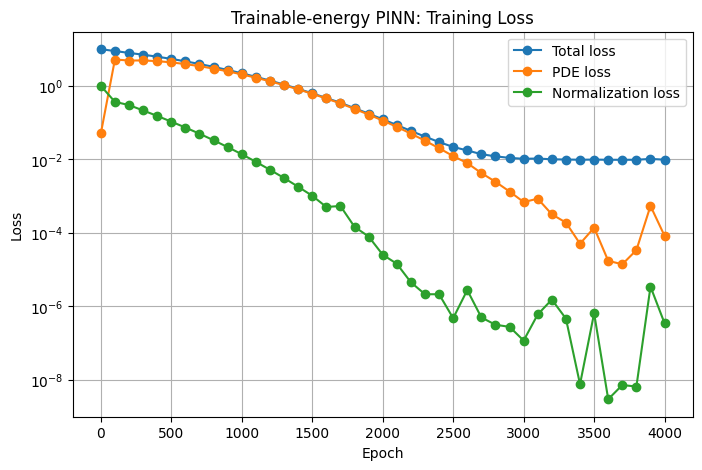

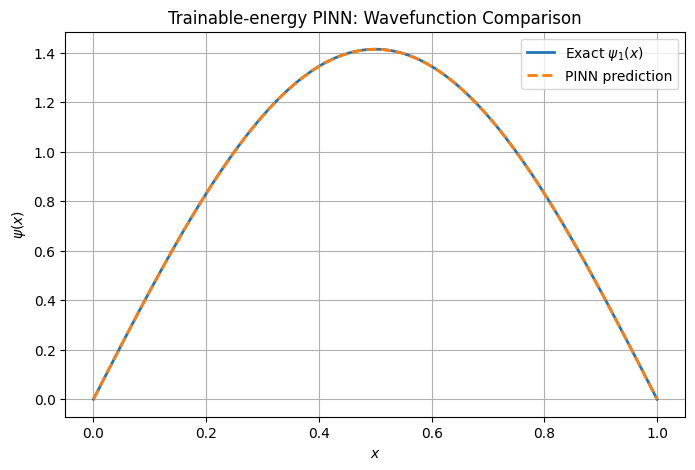

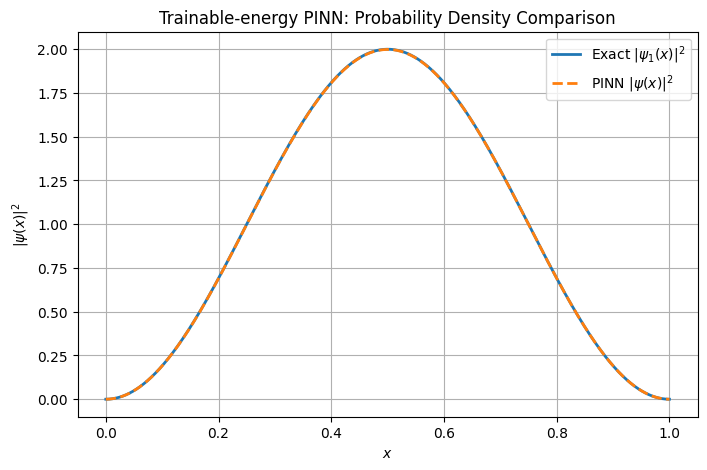

In [45]:

# ============================================================
# Trainable-energy evaluation and plots
# ============================================================

trainable_results = evaluate_model(trainable_energy_model)

print_evaluation("Trainable-energy PINN results", trainable_results)

plot_loss_history(
    trainable_history,
    title="Trainable-energy PINN: Training Loss"
)

plot_wavefunction(
    trainable_results,
    title="Trainable-energy PINN: Wavefunction Comparison"
)

plot_probability_density(
    trainable_results,
    title="Trainable-energy PINN: Probability Density Comparison"
)


## 10. Learned energy during training

This plot shows how the learned energy changes during training in the trainable-energy PINN case.

The exact ground-state energy is:

$$
E_1=\pi^2
$$

The goal is for the learned energy to approach this value.

If the learned energy converges close to $\pi^2$, it indicates that the network has successfully identified the ground-state eigenvalue of the infinite square well.

If the learned energy instead approaches a value close to:

$$
4\pi^2
$$

or

$$
9\pi^2
$$

then the network may have learned a higher excited state instead of the ground state.

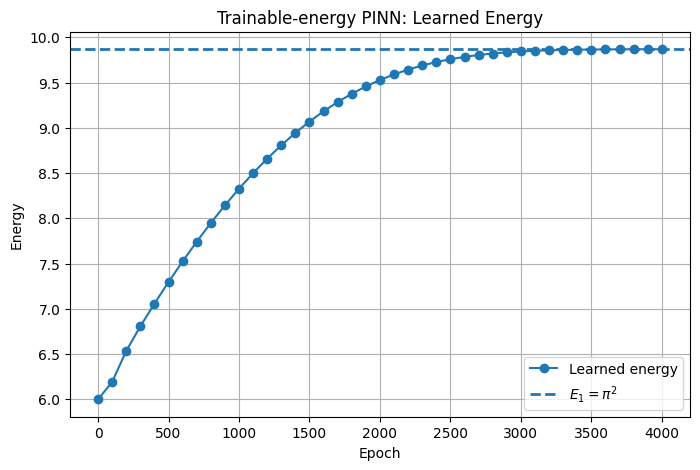

In [46]:

# ============================================================
# Plot learned energy during training
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(trainable_history["epoch"], trainable_history["energy"], marker="o", label="Learned energy")
plt.axhline(E_exact, linestyle="--", linewidth=2, label="$E_1 = \\pi^2$")
plt.xlabel("Epoch")
plt.ylabel("Energy")
plt.title("Trainable-energy PINN: Learned Energy")
plt.grid(True)
plt.legend()
plt.show()


## 11. Final comparison

This section compares the fixed-energy PINN and the trainable-energy PINN.

The fixed-energy model is easier because it already knows:

$$
E=\pi^2
$$

Therefore, it only needs to learn the wavefunction.

The trainable-energy model is more interesting because it must learn both:

$$
\psi_\theta(x)
$$

and

$$
E
$$

A successful PINN solution should satisfy three conditions:

First, the Schrödinger residual should be small:

$$
R_\theta(x)
\approx 0
$$

Second, the wavefunction should be normalized:

$$
\int_0^1 |\psi_\theta(x)|^2 dx
\approx 1
$$

Third, the energy should match the analytical ground-state energy:

$$
E
\approx
\pi^2
$$

The comparison table reports energy error, wavefunction error, and normalization error for both models.

In [47]:

# ============================================================
# Final comparison table
# ============================================================

comparison = [
    {
        "Model": "Fixed-energy PINN",
        "Predicted E": fixed_results["energy"],
        "Exact E": E_exact,
        "Energy Abs. Error": abs(fixed_results["energy"] - E_exact),
        "Wavefunction MSE": fixed_results["mse"],
        "Max Abs. Error": fixed_results["max_abs_error"],
        "Norm Integral": fixed_results["norm"]
    },
    {
        "Model": "Trainable-energy PINN",
        "Predicted E": trainable_results["energy"],
        "Exact E": E_exact,
        "Energy Abs. Error": abs(trainable_results["energy"] - E_exact),
        "Wavefunction MSE": trainable_results["mse"],
        "Max Abs. Error": trainable_results["max_abs_error"],
        "Norm Integral": trainable_results["norm"]
    }
]

# Print without requiring pandas
for row in comparison:
    print(row["Model"])
    print("-" * len(row["Model"]))
    print(f"Predicted E       : {row['Predicted E']:.8f}")
    print(f"Exact E           : {row['Exact E']:.8f}")
    print(f"Energy Abs. Error : {row['Energy Abs. Error']:.4e}")
    print(f"Wavefunction MSE  : {row['Wavefunction MSE']:.4e}")
    print(f"Max Abs. Error    : {row['Max Abs. Error']:.4e}")
    print(f"Norm Integral     : {row['Norm Integral']:.8f}")
    print()


Fixed-energy PINN
-----------------
Predicted E       : 9.86960411
Exact E           : 9.86960440
Energy Abs. Error : 2.9037e-07
Wavefunction MSE  : 5.0294e-10
Max Abs. Error    : 5.5015e-05
Norm Integral     : 1.00003040

Trainable-energy PINN
---------------------
Predicted E       : 9.86832428
Exact E           : 9.86960440
Energy Abs. Error : 1.2801e-03
Wavefunction MSE  : 1.6548e-07
Max Abs. Error    : 6.3705e-04
Norm Integral     : 0.99926758



## 12. Conclusion

This notebook demonstrates a small but complete Physics-Informed Neural Network project for quantum mechanics.

We solved the 1D time-independent Schrödinger equation:

$$
-\frac{d^2\psi(x)}{dx^2}=E\psi(x)
$$

for a particle in an infinite square well.

The boundary conditions were:

$$
\psi(0)=0
$$

and

$$
\psi(1)=0
$$

They were enforced exactly using the ansatz:

$$
\psi_\theta(x)=x(1-x)N_\theta(x)
$$

The normalization condition was enforced through the loss function:

$$
\int_0^1 |\psi_\theta(x)|^2 dx=1
$$

The exact ground-state solution is:

$$
\psi_1(x)=\sqrt{2}\sin(\pi x)
$$

with energy:

$$
E_1=\pi^2
$$

This project shows how a PINN can learn a quantum-mechanical wavefunction without supervised labels by using the governing differential equation as the training signal.

---

## Possible extensions

This notebook can be extended in several useful ways:

1. learn the first excited state $n=2$,
2. add an orthogonality constraint to separate different eigenstates,
3. solve the harmonic oscillator,
4. solve a finite square well,
5. solve a potential barrier problem,
6. extend the method to the time-dependent Schrödinger equation.

For excited states, an additional orthogonality constraint can be added:

$$
\int_0^1 \psi_m(x)\psi_n(x) dx = 0
$$

for:

$$
m \neq n
$$

This prevents the model from collapsing back to the ground state when learning higher modes.